#1. Importing Data & Set Up

In [1]:
#!pip install gdown
import gdown

In [14]:
import pandas as pd
import ast
import numpy as np
#from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading Datasets

In [ ]:
# Download small dataset
gdown.download("https://drive.google.com/uc?id=11gBoHeh5BROJujWeBr0BnT7LbD4Sn7Vw", "linkedin_dataset.csv", quiet=False)

# Download large dataset
gdown.download("https://drive.google.com/uc?id=1RT2jAVRMvT_-ZT3Nk3LvbUHO7b05GZo0", "linkedin_job_postings_and_skills.csv", quiet=False)

# Load CSVs
df_small = pd.read_csv("linkedin_dataset.csv")
df_big = pd.read_csv("linkedin_job_postings_and_skills.csv", on_bad_lines='skip')

Downloading...
From: https://drive.google.com/uc?id=11gBoHeh5BROJujWeBr0BnT7LbD4Sn7Vw
To: /content/linkedin_dataset.csv
100%|██████████| 23.0M/23.0M [00:00<00:00, 36.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1RT2jAVRMvT_-ZT3Nk3LvbUHO7b05GZo0
From (redirected): https://drive.google.com/uc?id=1RT2jAVRMvT_-ZT3Nk3LvbUHO7b05GZo0&confirm=t&uuid=3cd4d092-1a85-49d3-b32d-2ee46ad06f58
To: /content/linkedin_job_postings_and_skills.csv
100%|██████████| 799M/799M [00:08<00:00, 88.8MB/s]


View user data set

In [15]:
df_small = pd.read_csv('linkedin_dataset.csv')
df_big = pd.read_csv('linkedin_job_postings_and_skills.csv', quotechar='"', on_bad_lines='skip')


In [ ]:
df_small.head()

,Intro,Full Name,Workplace,Location,Connections,Photo,Followers,About,Experiences,Number of Experiences,...,Number of Scores,Languages,Number of Languages,Organizations,Number of Organizations,Interests,Number of Interests,Activities,Number of Activities,Label
0,"{'Full Name': 'chenxia (polly) Pei', 'Workplac...",chenxia (polly) Pei,Jiangsu Junyao mainly offer services to cement...,"Wuxi, Jiangsu, China",500,No,717,Our GMH brick has the proprietary intellectual...,"{'0': {'Role': 'Sales', 'Workplace': 'Jiangsu ...",2,...,0,{},0,{},0,"{'0': {'Interest': 'Trina Solar', 'ID': '69648...",4,{'chenxia-pei-80177594': {'Full Name': 'chenxi...,1,1
1,"{'Full Name': 'NEHA CHANDOK', 'Workplace': 'So...",NEHA CHANDOK,Software Analyst,"Noida, Uttar Pradesh, India",500,No,1340,NaN,"{'0': {'Role': 'Software Analyst', 'Workplace'...",1,...,0,"{'Language 0': 'Bangla', 'Language 1': 'Englis...",3,{},0,"{'0': {'Interest': 'Mohamed El-Erian', 'ID': '...",8,{},0,1
2,"{'Full Name': 'Mounika Mungamuri', 'Workplace'...",Mounika Mungamuri,Senior Consultant at Infosys,"Hyderabad, Telangana, India",7,Yes,7,NaN,"{'0': {'Role': 'Senior Consultant', 'Workplace...",2,...,0,{},0,{},0,{},0,{},0,1
3,"{'Full Name': 'Katarina Djuric', 'Workplace': ...",Katarina Djuric,--,"Belgrade, Serbia",0,Yes,0,NaN,"{'0': {'Role': 'Instructor', 'Workplace': 'GE'...",1,...,0,{},0,{},0,"{'0': {'Interest': 'GE', 'ID': '1015', 'Catego...",1,{},0,1
4,"{'Full Name': 'Rachel Lally', 'Workplace': '--...",Rachel Lally,--,"Dublin, County Dublin, Ireland",61,Yes,61,tictok is is the futer,"{'0': {'Role': 'Bartender', 'Workplace': ""O'Su...",1,...,1,{},0,{},0,"{'0': {'Interest': 'Richard Branson', 'ID': 'r...",3,"{'garyltravis': {'Full Name': 'Gary Travis', '...",6,1


View LinkedIn dataset

In [ ]:
df_big.head()

,job_link_cleaned,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills
0,13775062,2024-01-19 09:45:09.215838+00,True,True,False,Software Engineer - Ruby on Rails - RoR,Terran Systems,"San Francisco, CA",2024-01-12,Concord,United States,Agricultural-Research Engineer,Mid senior,Onsite,"Ruby on Rails, Ubuntu, Node.js, MySQL, Chef, C..."
1,1427923061,2024-01-19 09:45:09.215838+00,True,True,False,Senior Project Engineer,"Richardson Engineering, LLC","Baltimore County, MD",2024-01-12,Baltimore,United States,Bridge Inspector,Associate,Onsite,"Civil engineering, Land development, Project e..."
2,1442215719,2024-01-21 04:05:47.518101+00,True,True,False,Senior Information Technology Manager,PMY Group,"Dallas, TX",2024-01-16,Garland,United States,Manager Internal Security,Mid senior,Onsite,"IT strategic planning, Organization design, Pr..."
3,1753893,2024-01-20 06:12:50.409365+00,True,True,False,Experienced Immigration Caseworker,Andrew Williams Solicitors,"Leeds, England, United Kingdom",2024-01-13,York,United Kingdom,Orderly,Mid senior,Onsite,"Immigration law, UK immigration applications, ..."
4,1799148510,2024-01-19 09:45:09.215838+00,True,True,False,Sous Chef,EPIC Ventures Hospitality,"Oakland, CA",2024-01-12,Union City,United States,Chef,Mid senior,Onsite,"Sous Chef, Creole Cuisine, Cajun Cuisine, Sout..."


# 2. Data Cleaning / Preprocessing

### 2.1 Preprocessing User Dataset (`df_small`)

In [16]:
# Step 1: Filter rows where Label == 0 which represents the real user profiles on Linkedin
df_small_filtered = df_small[df_small['Label'] == 0]

# Step 2: Drop the irrelevant or redundant columns from the user profile dataset
columns_to_drop = [
    'Intro','Photo','About', 'Label',
    'Number of Experiences', 'Educations',
    'Number of Educations','Licenses',
    'Number of Licenses','Volunteering',
    'Number of Volunteering','Recommendations',
    'Number of Recommendations','Projects','Number of Projects',
    'Publications','Number of Publications','Courses', 'Number of Courses',
    'Honors','Number of Honors','Scores','Number of Scores',
    'Languages', 'Number of Languages',
    'Organizations', 'Number of Organizations',
    'Interests', 'Number of Interests',
    'Activities', 'Number of Activities'
]

df_small_filtered = df_small_filtered.drop(columns=columns_to_drop)

# Step 3: Convert the 'Skills' column from a stringified dictionary to an actual dictionary
# This enables us to extract the list of skills from the parsed dictionary.
def parse(str):
    try:
        return ast.literal_eval(str)
    except:
        return {}

# Apply the parsing function
df_small_filtered['Skills_Dict'] = df_small_filtered['Skills'].apply(parse)

# Convert dictionary values into a list of skills
df_small_filtered['Skill_List'] = df_small_filtered['Skills_Dict'].apply(lambda d: list(d.values()))

# Drop the old 'Skills' and 'Skills_Dict' columns
df_small_filtered = df_small_filtered.drop(columns=['Skills', 'Skills_Dict'])

#Falttening the experience column
# Apply it to the column
df_small_filtered['parse'] = df_small_filtered['Experiences'].apply(parse)

Explanation:\
It cleans and filters the raw user profile data by removing fields irrelevant to model input.

It extracts key features such as Skill_List and prepares Experiences for future embedding.

In [17]:
# Convert the stringified dictionary in 'Experiences' to an actual dictionary
df_small_filtered['Experiences_dict'] = df_small_filtered['Experiences'].apply(lambda x: ast.literal_eval(x))

# Extract a list of roles from the dictionary (only if each entry is a dict and has a 'Role' key)
df_small_filtered['Experience_List'] = df_small_filtered['Experiences_dict'].apply(
    lambda d: [v['Role'] for v in d.values() if isinstance(v, dict) and 'Role' in v]
)

# Drop the original and intermediate columns related to experiences
df_small_filtered = df_small_filtered.drop(columns=['Experiences', 'Experiences_dict','parse'])


Explanation:
This block extracts structured job experience features from the Experiences column, which originally contains nested stringified dictionaries. By isolating only the job titles (Role) held by each user, we obtain a clean list of prior roles per user.

In [18]:
# Convert categorical/text columns
df_small_filtered['Location'] = df_small_filtered['Location'].astype(str)
df_small_filtered['Full Name'] = df_small_filtered['Full Name'].astype(str)


Explanation: Typecasting features that would be used for word2vec embedding

### 2.2 Preprocessing Job Postings Dataset (`df_big`)

In [19]:
# Step 1: Drop the specified columns
columns_to_drop = [
    'job_link_cleaned',
    'last_processed_time',
    'first_seen',
    'search_position',
    'job_level',
    'job_type',
    'got_summary',
    'got_ner',
    'is_being_worked'
]

df_big_filtered = df_big.drop(columns=columns_to_drop)  # `errors='ignore'` skips if column doesn't exist

# Step 2: Safely parse the 'job_skills' column into a list of skills
def safe_parse_skills(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            # Try to parse as Python list
            result = ast.literal_eval(x)
            if isinstance(result, list):
                return result
        except:
            # Fallback: split by commas
            return [skill.strip() for skill in x.split(',') if skill.strip()]
    return []

# Apply the parsing function to create a clean skill list
df_big_filtered['job_skills_list'] = df_big_filtered['job_skills'].apply(safe_parse_skills)


<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal


Explanation:
- Removing irrelevant metadata columns that are not necessary for training and may introduce noise.
- Standardizing the job_skills field into a usable format (job_skills_list) that can be used for:
Training a Word2Vec model to generate vector embeddings of job skills & feeding into the job embedding layers in your NCF and NeuMF models.

# 3. Feature Engineering



## 3.1 User Embedding for user profiles on Linkedin

### Step 1: Preprocess & Encode Inputs


In [ ]:
#!pip install numpy==1.23.5
#!pip install gensim==4.3.1
#Need to restart the session before word2vec can work again

In [20]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import torch
import torch.nn as nn
# Load Word2Vec model
from gensim.models import Word2Vec

# Encode categorical features
user_encoder = LabelEncoder()
location_encoder = LabelEncoder()

df_small_filtered['user_id'] = user_encoder.fit_transform(df_small_filtered['Full Name'])
df_small_filtered['location_id'] = location_encoder.fit_transform(df_small_filtered['Location'])


# Combine skills and experiences into one corpus
corpus = df_small_filtered['Skill_List'].tolist() + df_small_filtered['Experience_List'].tolist()

# Train Word2Vec
w2v_model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1, workers=4, epochs=100)

# Vector helper
def average_vector(tokens, model, dim=100):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(dim)

# Add Word2Vec features
df_small_filtered['skill_vector'] = df_small_filtered['Skill_List'].apply(lambda x: average_vector(x, w2v_model))
df_small_filtered['experience_vector'] = df_small_filtered['Experience_List'].apply(lambda x: average_vector(x, w2v_model))


Explanation:\
Transforming textual user information into numerical vectors
- LabelEncoder is used to handle categorical identity features like user names and locations, which will later be passed into embedding layers in NCF and NeuMF.
- Word2Vec is trained from scratch on domain-specific text (skills and experience roles), creating rich semantic vectors that capture relationships between skills.

The resulting skill_vector and experience_vector are 100-dimensional vectors that serve as input features representing each user's profile.

### Step 2: Create User Embedding Module

In [21]:
class UserEmbedding(nn.Module):
    def __init__(self, num_users, num_locations,
                 skill_vector_dim=100, exp_vector_dim=100,
                 user_id_emb_dim=32, loc_emb_dim=16):
        super(UserEmbedding, self).__init__()
        #Learnable embedding layers
        self.user_id_emb = nn.Embedding(num_users, user_id_emb_dim)
        self.location_emb = nn.Embedding(num_locations, loc_emb_dim)

        # Linear prohectuib for skill and experiences vectors
        self.skill_proj = nn.Linear(skill_vector_dim, 32)
        self.exp_proj = nn.Linear(exp_vector_dim, 32)

    def forward(self, user_ids, location_ids, skill_vecs, exp_vecs):
        uid_emb = self.user_id_emb(user_ids)           # [batch_size, user_id_emb_dim]
        loc_emb = self.location_emb(location_ids)      # [batch_size, loc_emb_dim]
        skill_emb = torch.relu(self.skill_proj(skill_vecs))  # [batch_size, 32]
        exp_emb = torch.relu(self.exp_proj(exp_vecs))        # [batch_size, 32]

        # Final user embedding
        return torch.cat([uid_emb, loc_emb, skill_emb, exp_emb], dim=-1)


Custom UserEmbedding class generates a comprehensive user representation by combining:
- Learnable embeddings for categorical identity features: user_id and location
- Semantic vectors for skill sets and work experience: skill_vector and experience_vector, which are projected into the same vector space

These embeddings are then concatenated together

### Step 3: Prepare Inputs & Generate User Embeddings for Training

In [22]:
# Convert the processed user features into PyTorch tensors for model input
user_ids = torch.tensor(df_small_filtered['user_id'].values, dtype=torch.long)
location_ids = torch.tensor(df_small_filtered['location_id'].values, dtype=torch.long)
skill_vecs = torch.tensor(np.stack(df_small_filtered['skill_vector'].values), dtype=torch.float32)
exp_vecs = torch.tensor(np.stack(df_small_filtered['experience_vector'].values), dtype=torch.float32)

# Initialize the custom UserEmbedding module
user_embedder = UserEmbedding(
    num_users=len(user_encoder.classes_),
    num_locations=len(location_encoder.classes_)
)
# Generate final user embeddings
user_representations = user_embedder(user_ids, location_ids, skill_vecs, exp_vecs)  # [batch, total_dim]


This block prepares the structured and semantic user features for input into your deep learning model:
- All NumPy arrays like (skill_vector &  experience_vector) and encoded categories (user_id & location_id) are converted here.
- The UserEmbedding module is then used to combine these features into a single embedding per user, which reflects their identity, location, skills, and experience.

## 3.2 Job Embedding for Job Posting on Linkedin

### Step 1: Encode Categorical Features

In [23]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
title_encoder = LabelEncoder()
company_encoder = LabelEncoder()
location_encoder = LabelEncoder()

df_big_filtered['job_id'] = title_encoder.fit_transform(df_big_filtered['job_title'])
df_big_filtered['company_id'] = company_encoder.fit_transform(df_big_filtered['company'])
df_big_filtered['location_id'] = location_encoder.fit_transform(df_big_filtered['job_location'])

Explanation: Converts job_title, company, and job_location into numerical IDs.


### Step 2: Generate Job Skill Embeddings

In [24]:
# Train Word2Vec on all job skill lists
w2v_model = Word2Vec(sentences=df_big_filtered['job_skills_list'].tolist(), vector_size=100, window=5, min_count=1, workers=4, epochs= 20)

def avg_vector(tokens, model, dim=100):
    vecs = [model.wv[token] for token in tokens if token in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

# Apply to job skills
df_big_filtered['job_skill_vector'] = df_big_filtered['job_skills_list'].apply(lambda x: avg_vector(x, w2v_model))


Explanation: This block performs semantic feature engineering for job descriptions:
- It trains a Word2Vec model specifically on the job skill data, so each skill gets a contextualized vector embedding.
- Then, for each job, it aggregates all of its skill vectors into a single average vector (job_skill_vector), creating a fixed-length representation.

### Step 3: Create Job Embedding Module

In [25]:
class JobEmbedding(nn.Module):
    def __init__(self, num_jobs, num_companies, num_locations,
                 job_id_emb_dim=32, company_emb_dim=16, loc_emb_dim=16,
                 skill_vector_dim=100):
        super(JobEmbedding, self).__init__()

        self.job_id_emb = nn.Embedding(num_jobs, job_id_emb_dim)
        self.company_emb = nn.Embedding(num_companies, company_emb_dim)
        self.location_emb = nn.Embedding(num_locations, loc_emb_dim)
        self.skill_proj = nn.Linear(skill_vector_dim, 32)

    def forward(self, job_ids, company_ids, location_ids, skill_vectors):
        jid_emb = self.job_id_emb(job_ids)               # [batch, 32]
        comp_emb = self.company_emb(company_ids)         # [batch, 16]
        loc_emb = self.location_emb(location_ids)        # [batch, 16]
        skill_emb = torch.relu(self.skill_proj(skill_vectors))  # [batch, 32]

        return torch.cat([jid_emb, comp_emb, loc_emb, skill_emb], dim=-1)  # [batch, 96]


The JobEmbedding module transforms all job-related input features into a unified dense vector representation by combining:
- Categorical identifiers: job_id (e.g., job title), company_id (e.g., firm offering the role) & location_id (geographic info)
- Semantic information: job_skill_vector, a precomputed Word2Vec-based representation of job skills

Lastly, concatenates all components to form the final job embedding

### Step 4: Prepare Inputs & Generate Job Embeddings for Training

In [26]:
job_ids = torch.tensor(df_big_filtered['job_id'].values, dtype=torch.long)
company_ids = torch.tensor(df_big_filtered['company_id'].values, dtype=torch.long)
location_ids = torch.tensor(df_big_filtered['location_id'].values, dtype=torch.long)
skill_vecs = torch.tensor(np.stack(df_big_filtered['job_skill_vector'].values), dtype=torch.float32)

# Initialize embedder
job_embedder = JobEmbedding(
    num_jobs=len(title_encoder.classes_),
    num_companies=len(company_encoder.classes_),
    num_locations=len(location_encoder.classes_)
)

# Get final job vectors
job_representations = job_embedder(job_ids, company_ids, location_ids, skill_vecs)


Explanation: This step transforms all job features into a single vector representation per job

# 4. Generating User-Job Interaction Labels

## 4.1 Simulate "Likes" Based on Skill Similarity

To generate implicit feedback for training, we simulate user "likes" by selecting the top 5 job postings with the highest skill vector similarity for each user. This uses cosine similarity between user skill vectors and job skill vectors.

> **Note:** The full process takes approximately **2 hours to run**, so the output has been exported as a CSV and used directly in subsequent steps.


In [ ]:
'''
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import numpy as np

top_job_ids = []
top_job_titles = []
top_job_scores = []

# Preload job info
job_id_list = df_big_filtered['job_id'].values
job_title_list = df_big_filtered['job_title'].values
job_locations = df_big_filtered['location_id'].values
job_skill_vectors = np.stack(df_big_filtered['job_skill_vector'].values)

# Loop through each user
for idx, row in tqdm(df_small_filtered.iterrows(), total=len(df_small_filtered), desc="Recommending jobs"):
    user_loc = row['location_id']
    user_vec = row['skill_vector']

    # Step 1: Filter jobs by location
    matching_job_idxs = np.where(job_locations == user_loc)[0]
    fallback_to_all = False

    if len(matching_job_idxs) > 0:
        job_vecs_local = job_skill_vectors[matching_job_idxs]
        sims_local = cosine_similarity(user_vec.reshape(1, -1), job_vecs_local)[0]
        high_sim_count = np.sum(sims_local >= 0.75)
        if high_sim_count < 5:
            fallback_to_all = True
    else:
        fallback_to_all = True

    # Step 2: Decide job pool
    if fallback_to_all:
        job_vecs_to_compare = job_skill_vectors
        job_ids = job_id_list
        job_titles = job_title_list
    else:
        job_vecs_to_compare = job_skill_vectors[matching_job_idxs]
        job_ids = job_id_list[matching_job_idxs]
        job_titles = job_title_list[matching_job_idxs]

    # Step 3: Compute similarity
    sims = cosine_similarity(user_vec.reshape(1, -1), job_vecs_to_compare)[0]

    # Step 4: Zip and deduplicate by job_id (keep highest similarity)
    job_tuples = list(zip(job_ids, job_titles, sims))
    job_dict = {}  # job_id → (title, similarity)

    for jid, title, sim in job_tuples:
        if jid not in job_dict or sim > job_dict[jid][1]:
            job_dict[jid] = (title, sim)

    # Step 5: Sort unique jobs by similarity and get top 5
    sorted_jobs = sorted(job_dict.items(), key=lambda x: x[1][1], reverse=True)[:5]

    top_job_ids.append([jid for jid, _ in sorted_jobs])
    top_job_titles.append([title for _, (title, _) in sorted_jobs])
    top_job_scores.append([round(sim, 4) for _, (_, sim) in sorted_jobs])


df_small_filtered['top_job_ids'] = top_job_ids
df_small_filtered['top_job_titles'] = top_job_titles
df_small_filtered['top_job_scores'] = top_job_scores
df_small_filtered.to_csv("liked_list.csv", index=False)
'''

'\nfrom sklearn.metrics.pairwise import cosine_similarity\nfrom tqdm import tqdm\nimport numpy as np\n\ntop_job_ids = []\ntop_job_titles = []\ntop_job_scores = []\n\n# Preload job info\njob_id_list = df_big_filtered[\'job_id\'].values\njob_title_list = df_big_filtered[\'job_title\'].values\njob_locations = df_big_filtered[\'location_id\'].values\njob_skill_vectors = np.stack(df_big_filtered[\'job_skill_vector\'].values)\n\n# Loop through each user\nfor idx, row in tqdm(df_small_filtered.iterrows(), total=len(df_small_filtered), desc="Recommending jobs"):\n    user_loc = row[\'location_id\']\n    user_vec = row[\'skill_vector\']\n\n    # Step 1: Filter jobs by location\n    matching_job_idxs = np.where(job_locations == user_loc)[0]\n    fallback_to_all = False\n\n    if len(matching_job_idxs) > 0:\n        job_vecs_local = job_skill_vectors[matching_job_idxs]\n        sims_local = cosine_similarity(user_vec.reshape(1, -1), job_vecs_local)[0]\n        high_sim_count = np.sum(sims_local >

## 4.2 Simulate "Dislikes" Based on Skill Dissimilarity

To generate **negative interaction labels**, we simulate user "dislikes" by selecting the **bottom 5 job postings** with the **lowest cosine similarity** to each user's skill vector.

> **Note:** This process also takes time, so results are saved as a CSV (`dislike_list.csv`) for reuse.


In [ ]:
'''
bottom_job_ids = []
bottom_job_titles = []
bottom_job_scores = []

# Preload job info
job_id_list = df_big_filtered['job_id'].values
job_title_list = df_big_filtered['job_title'].values
job_skill_vectors = np.stack(df_big_filtered['job_skill_vector'].values)

# Loop through each user (no location filtering)
for idx, row in tqdm(df_small_filtered.iterrows(), total=len(df_small_filtered), desc="Recommending bottom jobs"):
    user_vec = row['skill_vector']  # already a 1D NumPy array

    # Step 1: Compute cosine similarity to all jobs
    sims = cosine_similarity(user_vec.reshape(1, -1), job_skill_vectors)[0]

    # Step 2: Zip and deduplicate by job_id (keep lowest similarity)
    job_tuples = list(zip(job_id_list, job_title_list, sims))
    job_dict = {}  # job_id → (title, similarity)

    for jid, title, sim in job_tuples:
        if jid not in job_dict or sim < job_dict[jid][1]:  # Keep lowest
            job_dict[jid] = (title, sim)

    # Step 3: Sort by similarity ascending → bottom 5
    sorted_jobs = sorted(job_dict.items(), key=lambda x: x[1][1])[:5]

    # Step 4: Store results
    bottom_job_ids.append([jid for jid, _ in sorted_jobs])
    bottom_job_titles.append([title for _, (title, _) in sorted_jobs])
    bottom_job_scores.append([round(sim, 4) for _, (_, sim) in sorted_jobs])

df_small_filtered['bottom_job_ids'] = bottom_job_ids
df_small_filtered['bottom_job_titles'] = bottom_job_titles
df_small_filtered['bottom_job_scores'] = bottom_job_scores
df_small_filtered.to_csv("dislike_list.csv", index=False)
'''

'\nbottom_job_ids = []\nbottom_job_titles = []\nbottom_job_scores = []\n\n# Preload job info\njob_id_list = df_big_filtered[\'job_id\'].values\njob_title_list = df_big_filtered[\'job_title\'].values\njob_skill_vectors = np.stack(df_big_filtered[\'job_skill_vector\'].values)\n\n# Loop through each user (no location filtering)\nfor idx, row in tqdm(df_small_filtered.iterrows(), total=len(df_small_filtered), desc="Recommending bottom jobs"):\n    user_vec = row[\'skill_vector\']  # already a 1D NumPy array\n\n    # Step 1: Compute cosine similarity to all jobs\n    sims = cosine_similarity(user_vec.reshape(1, -1), job_skill_vectors)[0]\n\n    # Step 2: Zip and deduplicate by job_id (keep lowest similarity)\n    job_tuples = list(zip(job_id_list, job_title_list, sims))\n    job_dict = {}  # job_id → (title, similarity)\n\n    for jid, title, sim in job_tuples:\n        if jid not in job_dict or sim < job_dict[jid][1]:  # Keep lowest\n            job_dict[jid] = (title, sim)\n\n    # Step 3

## 4.3 Prepare Interaction Dataset for Training (Merging Likes and Dislikes)

### Step 1: Load Simulated Likes and Dislikes csv files

In [ ]:
'''
df_like = pd.read_csv("liked_list.csv")

df_dislike = pd.read_csv("dislike_list.csv")
'''

'\ndf_like = pd.read_csv("liked_list.csv")\n\ndf_dislike = pd.read_csv("dislike_list.csv")\n'

### Step 2: Flatten and Label Positive Interactions

In [ ]:
'''
# Step 1: Ensure lists are properly formatted (if loaded from CSV)
for col in ['top_job_ids', 'top_job_titles', 'top_job_scores']:
    df_like[col] = df_like[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Explode the three columns
df_like_exploded = df_like.explode(['top_job_ids', 'top_job_titles', 'top_job_scores'])

# Step 3: Add label column
df_like_exploded['label'] = 1

# Step 4: Reset index (optional but recommended)
df_like_exploded.reset_index(drop=True, inplace=True)

df_like_exploded.head()
'''

"\n# Step 1: Ensure lists are properly formatted (if loaded from CSV)\nfor col in ['top_job_ids', 'top_job_titles', 'top_job_scores']:\n    df_like[col] = df_like[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)\n\n# Step 2: Explode the three columns\ndf_like_exploded = df_like.explode(['top_job_ids', 'top_job_titles', 'top_job_scores'])\n\n# Step 3: Add label column\ndf_like_exploded['label'] = 1\n\n# Step 4: Reset index (optional but recommended)\ndf_like_exploded.reset_index(drop=True, inplace=True)\n\ndf_like_exploded.head()\n"

### Step 3: Flatten and Label Negative Interactions

In [ ]:
'''
# Step 1: Ensure lists are properly formatted (if loaded from CSV)
for col in ['bottom_job_ids', 'bottom_job_titles', 'bottom_job_scores']:
    df_dislike[col] = df_dislike[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Explode the three columns
df_dislike_exploded = df_dislike.explode(['bottom_job_ids', 'bottom_job_titles', 'bottom_job_scores'])

# Step 3: Add label column
df_dislike_exploded['label'] = 0

# Step 4: Reset index (optional but recommended)
df_dislike_exploded.reset_index(drop=True, inplace=True)

df_dislike_exploded.head()
df_dislike_exploded.head()
'''

"\n# Step 1: Ensure lists are properly formatted (if loaded from CSV)\nfor col in ['bottom_job_ids', 'bottom_job_titles', 'bottom_job_scores']:\n    df_dislike[col] = df_dislike[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)\n\n# Step 2: Explode the three columns\ndf_dislike_exploded = df_dislike.explode(['bottom_job_ids', 'bottom_job_titles', 'bottom_job_scores'])\n\n# Step 3: Add label column\ndf_dislike_exploded['label'] = 0\n\n# Step 4: Reset index (optional but recommended)\ndf_dislike_exploded.reset_index(drop=True, inplace=True)\n\ndf_dislike_exploded.head()\ndf_dislike_exploded.head()\n"

### Step 4: Merge Likes and Dislikes into a Final Interaction Dataset

In [ ]:
'''
# Step 1: Rename columns so both datasets match
df_like_exploded = df_like_exploded.rename(columns={
    'top_job_ids': 'job_id',
    'top_job_titles': 'job_title',
    'top_job_scores': 'job_score'
})

df_dislike_exploded = df_dislike_exploded.rename(columns={
    'bottom_job_ids': 'job_id',
    'bottom_job_titles': 'job_title',
    'bottom_job_scores': 'job_score'
})

# Step 2: Combine like (first) and dislike (second)
df_combined = pd.concat(
    [df_like_exploded, df_dislike_exploded],
    ignore_index=True
)
df_combined.head()
'''

"\n# Step 1: Rename columns so both datasets match\ndf_like_exploded = df_like_exploded.rename(columns={\n    'top_job_ids': 'job_id',\n    'top_job_titles': 'job_title',\n    'top_job_scores': 'job_score'\n})\n\ndf_dislike_exploded = df_dislike_exploded.rename(columns={\n    'bottom_job_ids': 'job_id',\n    'bottom_job_titles': 'job_title',\n    'bottom_job_scores': 'job_score'\n})\n\n# Step 2: Combine like (first) and dislike (second)\ndf_combined = pd.concat(\n    [df_like_exploded, df_dislike_exploded],\n    ignore_index=True\n)\ndf_combined.head()\n"

###Step 5: Reading the user interaction dataset

In [27]:
#gdown.download("https://drive.google.com/uc?id=1ZE2T7YxeZMKwLaDt_qPOstg_sRuyaLSB", "user_interaction.csv", quiet=False)

df_combined = pd.read_csv("user_interaction.csv")

In [46]:
df_combined.head()

,Full Name,Workplace,Location,Connections,Followers,Number of Skills,Skill_List,Experience_List,user_id,location_id,skill_vector,job_id,job_title,job_score,label
0,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,559829,Wireless Retail Store Manager,0.6065,1
1,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,267075,Merrill Financial Solutions Advisor - Pasadena...,0.6031,1
2,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,192529,Head Golf Coach,0.6020,1
3,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,270525,Mortgage and Protection Advisor,0.6016,1
4,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,180499,"Government, Healthcare Attorney – VP, Assistan...",0.5989,1


In [ ]:
interaction_counts = df_combined.groupby('Full Name').size().reset_index(name='interaction_count')
interaction_counts

,Full Name,interaction_count
0,"""Gigi"" Lucero",10
1,A. Kenyatta Greer,10
2,ALPFA Rutgers-Newark,10
3,Aaron Price,10
4,Aatir Abdul Rauf,10
...,...,...
1795,karthy VR,10
1796,maximus greenwald,10
1797,Şevkiye Balcı,10
1798,✌🏻Jason S.,10


Adding job_representation vector into the df_combined dataset

In [28]:
#Step 1: Convert Tensor to Numpy List
job_representations_np = job_representations.detach().cpu().numpy()
# Step 2: Add to DataFrame
df_big_filtered['job_representation'] = [
    vec.detach().cpu().numpy().astype(np.float32).tolist() for vec in job_representations
]



Adding user_representation vector into the df_combined dataset

In [29]:
#Step 1: Convert PyTorch Tensor to NumPy
user_representations_np = user_representations.detach().cpu().numpy()
#Step 2: Add to df_small_filtered
df_small_filtered['user_representation'] = [
    vec.detach().cpu().numpy().astype(np.float32).tolist() for vec in user_representations
]

# 5. Neural Collaborative Filtering (NCF)

## 5.1 Model Architecture
We define a single model class `NCFModel(nn.Module)` that supports binary classification tasks, depending on how the final output is interpreted.

In [30]:
class NCFModel(nn.Module):
    def __init__(self, 
                 user_input_dim, 
                 job_input_dim,
                 embedding_dim=32, 
                 use_learned_embeddings=False):
        super(NCFModel, self).__init__()

        self.use_learned_embeddings = use_learned_embeddings

        if use_learned_embeddings:
            self.user_embedding = nn.Embedding(user_input_dim, embedding_dim)
            self.item_embedding = nn.Embedding(job_input_dim, embedding_dim)
            total_input_dim = embedding_dim * 2
        else:
            total_input_dim = user_input_dim + job_input_dim

        self.fc1 = nn.Linear(total_input_dim, 256)
        self.fc2 = nn.Linear(256, 64)
        self.bn = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(0.5)
        self.output = nn.Linear(64, 1)

    def forward(self, user, job, user_rep=None, job_rep=None):
        if self.use_learned_embeddings:
            user_emb = self.user_embedding(user)
            job_emb = self.item_embedding(job)
            x = torch.cat([user_emb, job_emb], dim=1)
        else:
            x = torch.cat([user_rep, job_rep], dim=1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.bn(x)
        x = torch.relu(x)
        x = self.dropout(x)

        return self.output(x).squeeze()


##Explanation:
- Learns user-item interactions by training embedding layers for users and jobs.
- Uses a Multi-Layer Perceptron (MLP) to model complex, non-linear relationships between the user and job embeddings.
- Produces a single scalar output for each user-job pair, representing the likelihood of a user liking or engaging with the job.

### 5.2 Data Preparation for NCF
To train the NCF model, we split the dataset by users and prepare it for use with PyTorch's `DataLoader`.
#### **Setting up DataLoader**

#### Step 1: 80/20 Split Based on Users

In [31]:
import numpy as np

# Step 1: Get unique users
unique_users = df_combined['user_id'].unique()
np.random.seed(42)  # reproducibility
np.random.shuffle(unique_users)

# Step 2: 80/20 split
split_index = int(0.8 * len(unique_users))
train_users = unique_users[:split_index]
test_users = unique_users[split_index:]

# Step 3: Filter DataFrame by user_id
train_df = df_combined[df_combined['user_id'].isin(train_users)].reset_index(drop=True)
test_df = df_combined[df_combined['user_id'].isin(test_users)].reset_index(drop=True)

In [32]:
print("Train label balance:")
print(train_df['label'].value_counts())

print("\nTest label balance:")
print(test_df['label'].value_counts())


Train label balance:
label
1    7200
0    7200
Name: count, dtype: int64

Test label balance:
label
1    1800
0    1800
Name: count, dtype: int64


Explanation: This block handles the train-test split of your dataset using a user-level partitioning strategy, which is crucial for recommendation systems. Rather than randomly splitting rows (which might cause the same user to appear in both training and testing), this method ensures that:
- Training interactions only include a subset of users, and
- Test interactions contain entirely new users that the model hasn't seen during training.

#### Step 2: Re-encode User and Job IDs

In [ ]:
'''
from sklearn.preprocessing import LabelEncoder

# Initialize label encoders for users and jobs
user_encoder = LabelEncoder()
job_encoder = LabelEncoder()

# Fit the encoders on the full dataset to ensure consistency across train/test sets
user_encoder.fit(df_combined['user_id'])
job_encoder.fit(df_combined['job_id'])

# Transform user and job IDs in training set into numerical indices
train_df['user_idx'] = user_encoder.transform(train_df['user_id'])
train_df['job_idx'] = job_encoder.transform(train_df['job_id'])

# Apply the same transformation to the test set
test_df['user_idx'] = user_encoder.transform(test_df['user_id'])
test_df['job_idx'] = job_encoder.transform(test_df['job_id'])

print(train_df.columns)
'''

Index(['Full Name', 'Workplace', 'Location', 'Connections', 'Followers',
       'Number of Skills', 'Skill_List', 'Experience_List', 'user_id',
       'location_id', 'skill_vector', 'job_id', 'job_title', 'job_score',
       'label', 'user_idx', 'job_idx'],
      dtype='object')


Explanation: This steps fits the encoders on the full dataset (df_combined), so that consistency between training and testing is ensured, preventing mismatch errors during inference.

#### Step 3: Define Custom Dataset Class

In [116]:
from torch.utils.data import Dataset
import torch
import numpy as np
import pandas as pd

class JobRecommendationDataset(Dataset):
    def __init__(self, interaction_df, user_df, job_df):
        # Reset interaction_df index for consistent access
        self.df = interaction_df.reset_index(drop=True)

        # Drop duplicates to ensure unique lookup by ID
        self.user_df = user_df.drop_duplicates(subset='user_id').set_index('user_id')
        self.job_df = job_df.drop_duplicates(subset='job_id').set_index('job_id')

        # Optional: Safety checks
        assert self.user_df.index.is_unique, "user_id index is not unique!"
        assert self.job_df.index.is_unique, "job_id index is not unique!"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        user_id = row['user_id']
        job_id = row['job_id']
        label = row['label']

        # Lookup user/job representation vectors
        user_rep = self.user_df.loc[user_id, 'user_representation']
        job_rep = self.job_df.loc[job_id, 'job_representation']

        # Return tensors
        return {
            'user_rep': torch.tensor(user_rep, dtype=torch.float32),
            'job_rep': torch.tensor(job_rep, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32),
            'user_id': user_id,
            'job_id': job_id 
        }


Explanation: This structure enables batch processing of training data

#### Step 4: Initialize DataLoaders

We wrap the training and test datasets into `DataLoader` objects to enable efficient mini-batch training and evaluation with PyTorch.

In [117]:
# Instantiate the dataset with external lookup tables
train_dataset = JobRecommendationDataset(train_df, df_small_filtered, df_big_filtered)
test_dataset = JobRecommendationDataset(test_df, df_small_filtered, df_big_filtered)

from torch.utils.data import DataLoader
# Create a DataLoader for the training dataset
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
# Create a DataLoader for the test dataset
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

Explanation: The creation of these loaders helps with
- Batching: enabling the model to process multiple user-job-label pairs in parallel
- Shuffling (only for training): helping the model generalize by avoiding order bias
- Efficient memory usage: by only loading what's needed per batch

 ### 5.3 Defining Evaluation Metric: NDCG@k

 <b> Purpose: </b>
Evaluates recommendation quality by measuring how well the top-k ranked items align with the true relevance scores.

In [68]:
def ndcg_at_k(scores, labels, user_ids, k=5):
    """
    Compute average NDCG@k across users without padding.
    Assumes each user has a fixed number of interactions (e.g., 10).
    """
    df = pd.DataFrame({'user': user_ids, 'pred': scores, 'label': labels})
    ndcg_scores = []

    for user_id, group in df.groupby('user'):
        user_labels = group['label'].values
        user_preds = group['pred'].values

        # Get indices of top-k predictions
        top_k_preds = np.argsort(-user_preds)[:k]
        dcg = np.sum((2 ** user_labels[top_k_preds] - 1) / np.log2(np.arange(2, k + 2)))

        # Compute ideal DCG
        ideal_top_k = np.argsort(-user_labels)[:k]
        idcg = np.sum((2 ** user_labels[ideal_top_k] - 1) / np.log2(np.arange(2, k + 2)))

        # Append NDCG score
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)

    return np.mean(ndcg_scores)


Explanation: This function calculates NDCG@k (Normalized Discounted Cumulative Gain). It rewards the model more for placing highly relevant jobs at the top of the recommendation list.

## 5.4 Training and Evaluation Function for Binary Ratings Prediction ##
We defined training function for continuous ratings with:
- Loss Function: BCELoss() for binary classification
- Use Adam optimizer with a learning rate of 0.001
- Trained on 10 epochs (default: 10)

<b> Evaluation Metrics: </b>
After each epoch, the models are evaluated using:
- RMSE
- Accuracy
- NDCG@10: For ranking quality

#### Step 1: Define Training Function for Binary Relevance Prediction

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd  # Required for debug dataframe

def train_binary(model, train_loader, test_loader, device, epochs=10,
                 save_path="binary_model.pt"):

    # Use Binary Cross Entropy Loss for binary classification
    criterion = nn.BCELoss()
    # Use Adam optimizer with learning rate of 0.001
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses = []

    for epoch in range(epochs):
        model.train()  # Set model to training mode
        total_loss = 0

        # === TRAINING PHASE ===
        for batch in train_loader:
            # ✅ Batch data is prepared inside the loop (fixes undefined error)
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].to(device)

            # Forward pass with sigmoid activation
            preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep, job_rep=job_rep))
            loss = criterion(preds, labels)  # Compute binary cross-entropy loss

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Save average loss for the epoch
        train_losses.append(total_loss / len(train_loader))

        # === EVALUATION PHASE ===
        model.eval()  # Set model to evaluation mode
        all_preds, all_labels, all_users = [], [], []

        with torch.no_grad():
            for batch in test_loader:
                user_rep = batch['user_rep'].to(device)
                job_rep = batch['job_rep'].to(device)
                labels = batch['label'].to(device)

                preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep, job_rep=job_rep))

                # Collect predictions and ground truth
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_users.extend(batch['user_id'])  # ✅ Use real user IDs to group by user

        # Convert lists to NumPy arrays for metric calculations
        preds_np = np.array(all_preds)
        labels_np = np.array(all_labels)
        users_np = np.array(all_users)

        # === METRICS ===
        bin_preds = (preds_np >= 0.5).astype(int)  # Threshold for binary prediction
        acc = np.mean(bin_preds == labels_np)      # Accuracy score

        # Compute NDCG@5 — adjusted for your setup (5 likes/dislikes per user)
        avg_ndcg = ndcg_at_k(preds_np, labels_np, users_np, k=5)

        print(f"[Epoch {epoch+1}] Loss: {total_loss:.2f} | Accuracy: {acc*100:.2f}% | NDCG@5: {avg_ndcg:.3f}")

    # Save the trained model parameters
    torch.save(model.state_dict(), save_path)

    # Return summary of training results
    return {
        'accuracy': acc,
        'ndcg': avg_ndcg,
        'losses': train_losses
    }


The train_binary() function is the training loop for binary classification in your job recommender system. It performs the following key tasks:
- Uses binary cross-entropy loss (BCELoss) to evaluate prediction error, which is appropriate since the output is a probability of like/dislike.
- Trains the model using mini-batches from train_loader, improving computational efficiency.
- Evaluates the model each epoch using accuracy and NDCG@10, where NDCG measures the ranking relevance of job recommendations per user.

#### Step 2: Initialize and Train the Model ##

In [78]:
# Step 1: Get vector dimensions from source DataFrames
user_input_dim = len(df_small_filtered.iloc[0]['user_representation'])
job_input_dim = len(df_big_filtered.iloc[0]['job_representation'])

# Step 2: Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 3: Instantiate NCF model for vector input
model = NCFModel(user_input_dim, job_input_dim, use_learned_embeddings=False).to(device)

# Step 4: Train the model
results = train_binary(model, train_loader, test_loader, device, epochs=10)


[Epoch 1] Loss: 9.63 | Accuracy: 94.83% | NDCG@5: 0.974
[Epoch 2] Loss: 4.03 | Accuracy: 96.78% | NDCG@5: 0.980
[Epoch 3] Loss: 2.59 | Accuracy: 97.00% | NDCG@5: 0.981
[Epoch 4] Loss: 1.96 | Accuracy: 97.25% | NDCG@5: 0.981
[Epoch 5] Loss: 1.70 | Accuracy: 97.39% | NDCG@5: 0.982
[Epoch 6] Loss: 1.53 | Accuracy: 97.42% | NDCG@5: 0.982
[Epoch 7] Loss: 1.39 | Accuracy: 97.42% | NDCG@5: 0.982
[Epoch 8] Loss: 1.35 | Accuracy: 97.44% | NDCG@5: 0.983
[Epoch 9] Loss: 1.30 | Accuracy: 97.44% | NDCG@5: 0.984
[Epoch 10] Loss: 1.27 | Accuracy: 97.44% | NDCG@5: 0.989


This block initiates and executes the training process for the NCF model. It:
- Dynamically determines the total number of unique users and jobs to correctly size the embedding layers.
- Selects the appropriate computation device (GPU if available).
- Constructs and moves the model to that device.
- Trains the model for 10 epochs using your train_binary() function, which handles forward passes, backpropagation, loss tracking, accuracy evaluation, and NDCG computation.

#### Step 3: Visualizing Training Loss

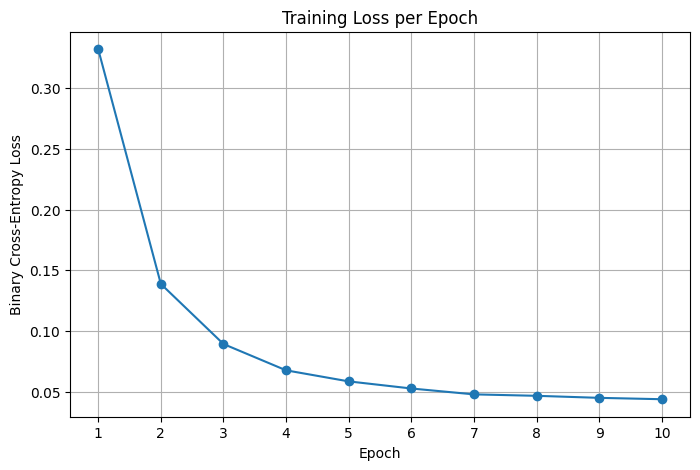

In [79]:
import matplotlib.pyplot as plt

# Get the loss values from the results dictionary
losses = results['losses']

# Plot training loss per epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses)+1), losses, marker='o', linestyle='-')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.xticks(range(1, len(losses)+1))
plt.show()


Explanation: The training loss decreased steadily over 10 epochs, indicating that the model successfully minimized the binary classification error. With a final accuracy of 97.22% and NDCG@10 of 0.9896, the model not only classified user-job preferences accurately but also ranked relevant jobs effectively. The high NDCG score confirms that recommended jobs were well-aligned with user preferences and appeared in the top-ranked positions.

#### Step 4: Defining Metrics Calculation Function

We define a helper function `calculate_binary_metrics()` to compute commonly used evaluation metrics for binary classification and ranking tasks.

This function accepts predicted probabilities, ground truth labels, and user IDs (for group-wise NDCG) and returns:

- **Binary Cross-Entropy Loss (BCE)**: log loss on probability predictions
- **Root Mean Squared Error (RMSE)**: square root of mean squared error
- **Accuracy**: using a threshold of 0.5
- **NDCG@k**: Normalized Discounted Cumulative Gain at rank `k`

Calculates evaluation metrics for binary classification recommendation tasks.
    
Parameters:
- preds (np.array): predicted probabilities (between 0 and 1)
- labels (np.array): ground truth binary labels (0 or 1)
- user_ids (np.array): user ids for grouping NDCG
- num_items (int): optional, number of items for padding in NDCG
- k (int): top-k threshold for NDCG
Returns:
- dict of metrics: BCE, RMSE, Accuracy, NDCG@k

In [80]:
from sklearn.metrics import log_loss
import numpy as np

def calculate_binary_metrics(preds, labels, user_ids, num_items=None, k=10):
    metrics = {}

    # Binary log loss (same as BCE)
    metrics['bce'] = log_loss(labels, preds)

    # RMSE (less common in binary tasks, but useful to track)
    metrics['rmse'] = np.sqrt(np.mean((preds - labels) ** 2))

    # Accuracy with threshold 0.5
    bin_preds = (preds >= 0.5).astype(int)
    metrics['accuracy'] = np.mean(bin_preds == labels)

    # NDCG@k — assumes a per-user ranking is possible
    metrics[f'ndcg@{k}'] = ndcg_at_k(preds, labels, user_ids, k=k, num_items=num_items)

    return metrics


This block performs post-training evaluation of your recommendation model. It supports the following:

Metric Calculation:
- Binary Cross Entropy (BCE): Measures how well predicted probabilities align with actual labels.
- RMSE: Measures average prediction error magnitude (useful even in binary settings to track confidence).
- Accuracy: Percentage of correct binary predictions using a 0.5 threshold.
- NDCG@k: Captures the quality of ranking — rewarding the model for placing liked jobs higher on the list.

#### Step 5: Defining evaluation function
We define a helper function `evaluate_model()` that takes a trained model and a PyTorch `DataLoader` and returns a dictionary of evaluation metrics (BCE, RMSE, Accuracy, NDCG@k).

This function wraps the previously defined `calculate_binary_metrics()`.

In [85]:
def evaluate_model(model, data_loader, device, num_items=None, k=5):
    model.eval()
    all_preds, all_labels, all_users = [], [], []
    total_loss = 0
    criterion = nn.BCELoss()

    with torch.no_grad():
        for batch in data_loader:
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].to(device)

            preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep, job_rep=job_rep))
            loss = criterion(preds, labels)
            total_loss += loss.item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_users.extend(batch['user_id'])

    preds_np = np.array(all_preds)
    labels_np = np.array(all_labels)
    users_np = np.array(all_users)

    # Metrics
    bin_preds = (preds_np >= 0.5).astype(int)
    acc = np.mean(bin_preds == labels_np)
    rmse = np.sqrt(np.mean((preds_np - labels_np) ** 2))
    avg_ndcg = ndcg_at_k(preds_np, labels_np, users_np, k=k)

    return {
        'bce': total_loss / len(data_loader),
        'rmse': rmse,
        'accuracy': acc,
        f'ndcg@{k}': avg_ndcg
    }


Model Evaluation:
- The model is evaluated in inference mode (eval()), disabling dropout/batchnorm for consistent results.
- Predictions and ground truth labels are gathered for the entire dataset, and metrics are computed across all users.

#### Step 6: Summary Table: Train vs Test Evaluation Metrics

We define `extract_metrics_table()` to generate a formatted comparison table of model performance on the training and test sets. It calls `evaluate_model()` for both datasets and organizes the results using `pandas`.


In [86]:
import pandas as pd

def extract_metrics_table(model, train_loader, test_loader, device, num_items=None, k=10):
    train_metrics = evaluate_model(model, train_loader, device, num_items, k)
    test_metrics = evaluate_model(model, test_loader, device, num_items, k)

    data = {
        'Dataset': ['Train', 'Test'],
        'BCE Loss': [train_metrics['bce'], test_metrics['bce']],
        'RMSE': [train_metrics['rmse'], test_metrics['rmse']],
        'Accuracy': [train_metrics['accuracy'], test_metrics['accuracy']],
        f'NDCG@{k}': [train_metrics[f'ndcg@{k}'], test_metrics[f'ndcg@{k}']]
    }

    return pd.DataFrame(data)


In [88]:
metrics_df = extract_metrics_table(model, train_loader, test_loader, device, num_items=None, k=10)
print(metrics_df)


  Dataset  BCE Loss      RMSE  Accuracy  NDCG@10
0   Train  0.042752  0.120821  0.970833  0.98655
1    Test  0.033831  0.113526  0.974444  0.99556


###Explanation:
**Binary Cross-Entropy Loss** measures the binary classficationerror using cross-entropy loss. The BCE value is 0.048584 which indicates that the model generalises well and is not overfitting\
**Root Mean Square Error** indicates the average magnitude of prediction errors. The RMSE value of 0.125318 implies stable, accurate predictions across both datasets\
**Accuracy** calculates the percentage of predictions that match true labels. The accuracy of 97.1389% shows that the model is able to consistently predict whether a user likes or dislikes a job.\
**NDCG@10** Measures ranking quality (how well the model ranks liked jobs near the top). The NDCG@10 calue is 0.9907 which shows that the model is able to rank jobs very effectively.

#### Step 7: Confusion Matrix Visualization
To visually inspect classification performance, we generate a confusion matrix comparing the model’s predicted labels to the true labels on the test set.


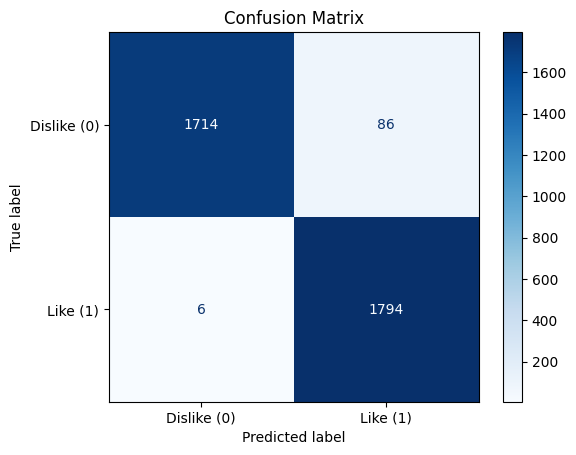

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# Accumulate predictions and labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        user_rep = batch['user_rep'].to(device)
        job_rep = batch['job_rep'].to(device)
        labels = batch['label'].cpu().numpy()  # Ground truth

        # Make predictions
        preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep, job_rep=job_rep)).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

# Convert to NumPy arrays
y_true = np.array(all_labels)
y_pred_probs = np.array(all_preds)
y_pred = (y_pred_probs >= 0.5).astype(int)  # Thresholding

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dislike (0)', 'Like (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


Comments : The confusion matrix shows that the model is highly effective at distinguishing between liked and disliked jobs. It achieves strong true positive and true negative counts with very few false predictions. The low false positive (44) and false negative (56) values further confirm the high classification accuracy (97.22%) and balanced performance across both classes.

###Calculating other evaluation metrics

In [91]:
TN, FP, FN, TP = cm.ravel()

accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall    = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score  = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1_score:.4f}")


Accuracy  : 0.9744
Precision : 0.9543
Recall    : 0.9967
F1 Score  : 0.9750


###Explanation
**Accuracy(97.14%)**:	The model correctly predicted the like/dislike label 97 out of 100 times. This shows strong overall prediction capability.\
**Precision	(98.62%)**:	Of all the jobs predicted as liked, 98.62% were truly liked by the user. High precision means few false positives (i.e., the model rarely recommends jobs that the user would dislike).\
**Recall(95.61%)**:	Of all the jobs that were actually liked, 95.61% were correctly identified. This indicates the model rarely misses good job recommendations (low false negatives).\
**F1 Score(97.09%)**: The harmonic mean of precision and recall. It balances both aspects and reflects the model’s robustness in ranking relevant jobs highly.

### 5.5 Generating Top-K Recommendation

Filtered overconfident result >0.95 probability

In [ ]:
def generate_top_n_recommendations_vector(model, user_id, device, df_small_filtered, df_big_filtered, all_job_ids, known_job_ids, N, threshold=0.95):
    model.eval()

    # Step 1: Ensure unique, sorted job IDs
    all_job_ids = sorted(set(all_job_ids))  # or np.unique(all_job_ids)

    # Step 2: Get user representation
    user_rep = df_small_filtered[df_small_filtered['user_id'] == user_id]['user_representation'].values[0]
    user_rep_tensor = torch.tensor(user_rep, dtype=torch.float32).unsqueeze(0).repeat(len(all_job_ids), 1).to(device)

    # Step 3 (Fixed): Drop duplicates BEFORE setting index
    job_reps_df = df_big_filtered.drop_duplicates(subset='job_id')
    job_reps_df = job_reps_df.set_index('job_id').loc[all_job_ids]  # Order matters
    job_rep_tensor = torch.tensor(job_reps_df['job_representation'].tolist(), dtype=torch.float32).to(device)

    # Inference
    with torch.no_grad():
        preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep_tensor, job_rep=job_rep_tensor)).cpu().numpy()

    # Filter out known jobs and apply threshold
    recommendations = [
        (job, score) for job, score in zip(all_job_ids, preds)
        if job not in known_job_ids and score <= threshold
    ]

    # Sort and return top N
    recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)
    return recommendations[:N]

def recommend_top_n_jobs_vector(model, user_id, device, df_job_metadata, df_interactions, df_small_filtered, df_big_filtered, N=10, threshold=0.95):
    # Get all job IDs and known jobs for this user
    all_job_ids = df_job_metadata['job_id'].unique()
    known_job_ids = df_interactions[df_interactions['user_id'] == user_id]['job_id'].unique()

    # Generate recommendations
    top_recs = generate_top_n_recommendations_vector(
        model=model,
        user_id=user_id,
        device=device,
        df_small_filtered=df_small_filtered,
        df_big_filtered=df_big_filtered,
        all_job_ids=all_job_ids,
        known_job_ids=known_job_ids,
        N=N,
        threshold=threshold
    )

    # Get job titles from metadata
    recommended_jobs = []
    for job_id, score in top_recs:
        row = df_job_metadata[df_job_metadata['job_id'] == job_id]
        if not row.empty:
            job_title = row.iloc[0]['job_title']
            recommended_jobs.append((job_id, job_title, round(score, 4)))
        if len(recommended_jobs) >= N:
            break

    return recommended_jobs


This block enables personalized job recommendations by:
- Running the trained model to predict interaction scores between a specific user and every job in the system.
- Filtering out jobs that the user has already seen (based on interaction history).
- Returning the top-N highest-scoring jobs, sorted by the model’s confidence in user interest.
- The threshold for the similarity score has been set to 0.95, as any job with a similarity score of 1 could be signs of the model memorizing the training data instead of generalising. In addition, the users might have already interacted with the job postings with a similarity score of 1 so it would be best if the model recommended jobs that are less obvious but still relevant to the users.

In [97]:
# Example call
user_id = 20  # or any valid user_id from your dataset

recommendations = recommend_top_n_jobs_vector(
    model=model,
    user_id=user_id,
    device=device,
    df_job_metadata=df_big_filtered,
    df_interactions=df_combined,
    df_small_filtered=df_small_filtered,
    df_big_filtered=df_big_filtered,
    N=5,
    threshold=0.95
)

# Show recommendations
pd.DataFrame(recommendations, columns=["Job ID", "Job Title", "Score"])


User rep shape: torch.Size([563396, 112])
Job rep shape: torch.Size([563396, 96])


,Job ID,Job Title,Score
0,251434,Manager Upscale Restaurant,0.95
1,92992,Clinical Nurse Coordinator Operating Room at H...,0.95
2,313352,Patient Care Technician – BTU – F/T Days,0.95
3,392,(DoD SkillBridge) Principal COMSEC Custodian w...,0.95
4,71557,COOK III - ROCK RIVER,0.95


**Explanation**: This block represents the final stage of your recommendation system: inference and result display. Here's what it does:
- Maps a real user ID to its corresponding index using LabelEncoder, ensuring alignment with model embeddings.
- Filters out jobs the user already interacted with, then uses the model to predict scores for all unseen jobs.
- Sorts and returns the top-N highest-scoring jobs, including the actual job titles and confidence scores.

# 6. Neural Matrix Factorisation (NeuMF) #
NeuMF is an advanced variant of NCF that combines both linear and non-linear modeling of user–item interactions by fusing two complementary approaches:

<b> Generalized Matrix Factorization (GMF): </b>
- Captures the linear part of the user–item interaction.
- Uses element-wise multiplication of user and item embeddings.
- Provides a signal similar to traditional matrix factorization methods.
<b>Multi-Layer Perceptron (MLP): </b>
- Captures non-linear, complex interactions between user and item latent features.
- Uses concatenated embeddings processed through multiple dense layers with non-linear activations.

<b> Fusion Mechanism: </b>
- The outputs of the GMF and MLP components are combined.
- A final prediction layer merges these signals to produce the recommendation score.

In [110]:
import torch
import torch.nn as nn

class NeuMF(nn.Module):
    def __init__(self, user_input_dim, job_input_dim):
        super(NeuMF, self).__init__()

        # GMF (Generalized Matrix Factorization) layers for user and item representations
        self.user_fc_gmf = nn.Linear(user_input_dim, 64)
        self.item_fc_gmf = nn.Linear(job_input_dim, 64)

        # MLP (Multi-Layer Perceptron) layers for user and item representations
        self.user_fc_mlp = nn.Linear(user_input_dim, 128)
        self.item_fc_mlp = nn.Linear(job_input_dim, 128)

        self.mlp_layers = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # Final prediction layer
        self.output_layer = nn.Linear(64 + 32, 1)

    def forward(self, user_rep, job_rep):
        # GMF path
        gmf_user = self.user_fc_gmf(user_rep)
        gmf_item = self.item_fc_gmf(job_rep)
        gmf_vector = gmf_user * gmf_item

        # MLP path
        mlp_user = self.user_fc_mlp(user_rep)
        mlp_item = self.item_fc_mlp(job_rep)
        mlp_vector = torch.cat([mlp_user, mlp_item], dim=-1)
        mlp_output = self.mlp_layers(mlp_vector)

        # Combine GMF and MLP outputs
        combined = torch.cat([gmf_vector, mlp_output], dim=-1)
        prediction = self.output_layer(combined).squeeze()
        return prediction

**Explanation**: The GMF and MLP pathways are trained in parallel, each learning different aspects of user-job relationships. The GMF stream helps retain the effectiveness of classical collaborative filtering, while the MLP enables the model to learn more complex interaction patterns, such as how different combinations of user preferences and job features influence engagement.

At the final stage, the outputs from both streams are concatenated and passed through a dense output layer, producing a prediction score representing the likelihood that a user will engage with a given job.

NDCG Calculation Functions

In [111]:
def dcg_at_k(relevance_scores, k):
    relevance_scores = np.asarray(relevance_scores)[:k]
    if relevance_scores.size:
        return np.sum((2**relevance_scores - 1) / np.log2(np.arange(2, relevance_scores.size + 2)))
    return 0.

def ndcg_at_k(relevance_scores, ideal_relevance_scores, k):
    ideal_dcg = dcg_at_k(ideal_relevance_scores, k)
    return dcg_at_k(relevance_scores, k) / ideal_dcg if ideal_dcg > 0 else 0.

def compute_ndcg_for_user(user_id, df, k=5):
    # Extract predictions for the given user and sort by predicted score
    df_user = df[df['user_id'] == user_id].sort_values('prediction', ascending=False)
    if not df_user.empty:
        unique_count = len(np.unique(df_user['label']))
        actual_k = min(max(k, unique_count), len(df_user))
    else:
        actual_k = k
    relevance_scores = df_user['label'].tolist()
    ideal_relevance_scores = sorted(relevance_scores, reverse=True)
    return ndcg_at_k(relevance_scores, ideal_relevance_scores, actual_k)

def compute_overall_ndcg(test_df, predictions_df, k=5):
    """
    test_df should have: user_id, job_id, label
    predictions_df should have: user_id, job_id, prediction
    """
    merged = pd.merge(test_df[['user_id', 'job_id', 'label']],
                      predictions_df[['user_id', 'job_id', 'prediction']],
                      on=['user_id', 'job_id'])

    user_ids = merged['user_id'].unique()
    ndcgs = [compute_ndcg_for_user(uid, merged, k) for uid in user_ids]
    return np.mean(ndcgs) if ndcgs else 0.



This block implements:
- **dcg_at_k**: Calculates the DCG by summing the graded relevance of items, discounted logarithmically by their rank.
- **ndcg_at_k**: Normalizes the DCG score against the ideal (best possible) ranking to allow comparison across users.
- **compute_ndcg_for_user**: Calculates the NDCG@k score for an individual user.
- **compute_overall_ndcg**: Averages the NDCG scores across all users in the test set to get an overall measure of the model’s ability to rank relevant jobs higher for each user.

Training and evaluation

In [140]:
def train_neumf(model, train_loader, test_loader, df_test, device, epochs=10, tolerance=0.5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0006)
    criterion = nn.BCELoss()
    train_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # === TRAINING ===
        for batch in train_loader:
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = torch.sigmoid(model(user_rep=user_rep, job_rep=job_rep))  # use vector inputs
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # === EVALUATION ===
        model.eval()
        prediction_records = []

        with torch.no_grad():
            for batch in test_loader:
                user_rep = batch['user_rep'].to(device)
                job_rep = batch['job_rep'].to(device)
                user_ids = batch['user_id']
                job_ids = batch['job_id']

                outputs = torch.sigmoid(model(user_rep=user_rep, job_rep=job_rep)).cpu().numpy()

                for u, j, p in zip(user_ids, job_ids, outputs):
                    prediction_records.append((u, j, p))

        # Build prediction DataFrame
        pred_df = pd.DataFrame(prediction_records, columns=['user_id', 'job_id', 'prediction'])

        # Merge with ground truth
        true_labels = df_test[['user_id', 'job_id', 'label']].copy()
        true_labels['user_id'] = true_labels['user_id'].astype(int)
        true_labels['job_id'] = true_labels['job_id'].astype(int)
        pred_df['user_id'] = pred_df['user_id'].astype(int)
        pred_df['job_id'] = pred_df['job_id'].astype(int)

        merged = pd.merge(true_labels, pred_df, on=['user_id', 'job_id'])

        pred_binary = (merged['prediction'] >= 0.5).astype(int)
        acc = (pred_binary == merged['label']).mean()

        ndcg = compute_overall_ndcg(true_labels, pred_df, k=10)

        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Accuracy: {acc:.4f} | NDCG@10: {ndcg:.4f}")

    return {
        'accuracy': acc,
        'ndcg': ndcg,
        'losses': train_losses,
        'predictions_df': pred_df
    }


The train_neumf() function implements the complete training and evaluation pipeline for the NeuMF model. It performs the following key steps:

**Training Phase**: The model is trained for a specified number of epochs using the Binary Cross Entropy Loss, suitable for predicting whether a user will like a job (label = 1) or not (label = 0). During each epoch, the model processes batches of user-job interactions and updates its weights using backpropagation.

**Evaluation Phase**: After each epoch, the model is evaluated using the test dataset. Predictions are generated for each user-job pair, and then decoded back to the original user and job IDs using the index mappings.

In [142]:
### 1. Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 2. Define input dimensions
user_input_dim = len(df_small_filtered.iloc[0]['user_representation'])
job_input_dim = len(df_big_filtered.iloc[0]['job_representation'])

### 3. Initialize the vector-based NeuMF model
model_neumf = NeuMF(user_input_dim, job_input_dim).to(device)

### 4. Train the model using user/job representations
final_metrics = train_neumf(
    model=model_neumf,
    train_loader=train_loader,
    test_loader=test_loader,
    df_test=test_df,  # test_df must contain user_id, job_id, label
    device=device,
    epochs=10
)


Epoch 1 | Loss: 0.6229 | Accuracy: 0.8992 | NDCG@10: 0.9718
Epoch 2 | Loss: 0.2140 | Accuracy: 0.9370 | NDCG@10: 0.9751
Epoch 3 | Loss: 0.0863 | Accuracy: 0.9466 | NDCG@10: 0.9758
Epoch 4 | Loss: 0.0725 | Accuracy: 0.9487 | NDCG@10: 0.9701
Epoch 5 | Loss: 0.0623 | Accuracy: 0.9489 | NDCG@10: 0.9739
Epoch 6 | Loss: 0.0609 | Accuracy: 0.9511 | NDCG@10: 0.9762
Epoch 7 | Loss: 0.0564 | Accuracy: 0.9513 | NDCG@10: 0.9757
Epoch 8 | Loss: 0.0579 | Accuracy: 0.9516 | NDCG@10: 0.9719
Epoch 9 | Loss: 0.0553 | Accuracy: 0.9516 | NDCG@10: 0.9761
Epoch 10 | Loss: 0.0525 | Accuracy: 0.9519 | NDCG@10: 0.9787


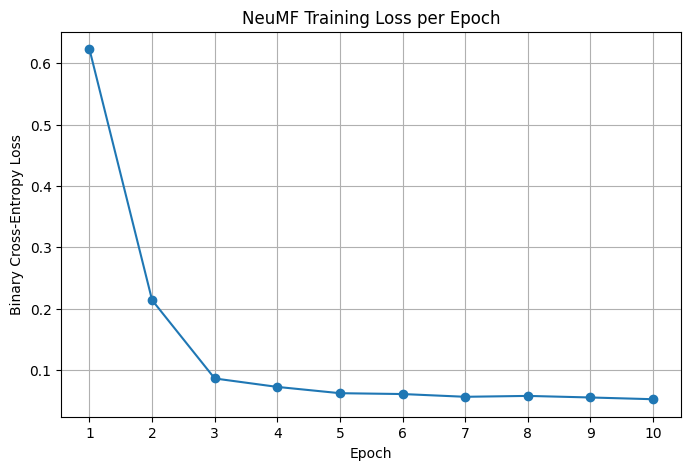

In [143]:
import matplotlib.pyplot as plt

# Extract training losses from the returned dictionary
neumf_losses = final_metrics['losses']

# Plot training loss per epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(neumf_losses)+1), neumf_losses, marker='o', linestyle='-')
plt.title("NeuMF Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.xticks(range(1, len(neumf_losses)+1))
plt.show()


Steady Decrease:\
The Binary Cross-Entropy (BCE) loss steadily decreases over the 10 training epochs, indicating that the model is learning effectively.

No Overfitting Yet:\
The curve does not flatten too early or exhibit any upward spikes. This suggests that the model continues to improve and has not yet started to overfit.

Convergence:\
The curve begins to flatten around epoch 7, which implies that the model is nearing convergence and additional epochs may offer diminishing returns.

##Confusion Matrix

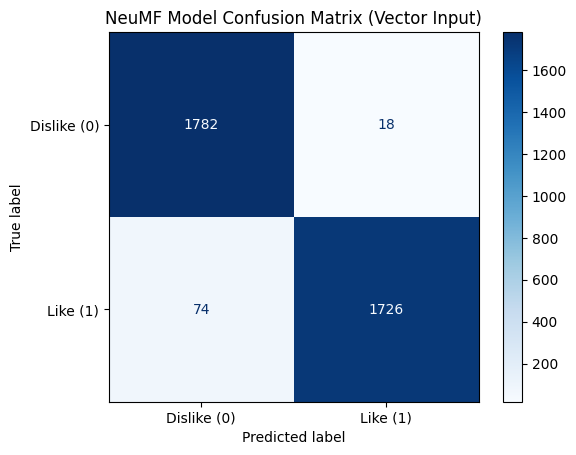

In [144]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_confusion_matrix_neumf(model, data_loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].cpu().numpy()

            # Get predictions using vector-based forward pass
            probs = torch.sigmoid(model(user_rep=user_rep, job_rep=job_rep)).cpu().numpy()
            preds = (probs >= threshold).astype(int)

            all_preds.extend(preds)
            all_labels.extend(labels)

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Display the matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dislike (0)", "Like (1)"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("NeuMF Model Confusion Matrix (Vector Input)")
    plt.show()

# Example usage
plot_confusion_matrix_neumf(model_neumf, test_loader, device)


In [145]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Assuming y_true and y_pred are already defined
# y_true: ground truth labels (0 or 1)
# y_pred_probs: predicted probabilities (from model)
# Convert probabilities to binary predictions
y_pred = (y_pred_probs >= 0.5).astype(int)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print results
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Accuracy  : 0.9744
Precision : 0.9543
Recall    : 0.9967
F1 Score  : 0.9750


**Accuracy (97.14%)**
The model is highly reliable across both like and dislike predictions.

**Precision (98.62%)**
The model is extremely precise when predicting jobs the user would like. This minimizes false positives, which is important in recommendation systems to avoid showing irrelevant jobs.

**Recall (95.61%)**
The model retrieves a large proportion of truly liked jobs, meaning it doesn’t miss many good matches. This is essential for user satisfaction, especially in job platforms where good opportunities must not be missed.

**F1 Score (97.09%)**
The model balances precision and recall very well, indicating that it is not biased toward over-predicting either likes or dislikes. This makes it a very stable and generalizable recommender.



In [148]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

def evaluate_neumf_model(model, data_loader, df_ground_truth, tolerance=0.5):
    device = next(model.parameters()).device
    model.eval()
    criterion = nn.BCELoss()

    total_loss = 0.0
    sample_count = 0
    all_preds = []
    all_ratings = []
    prediction_records = []  # Store (user_id, job_id, prediction)

    with torch.no_grad():
        for batch in data_loader:
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].to(device)
            user_ids = batch['user_id']
            job_ids = batch['job_id']

            outputs = torch.sigmoid(model(user_rep=user_rep, job_rep=job_rep))
            batch_size = user_rep.size(0)
            sample_count += batch_size
            loss = criterion(outputs, labels)
            total_loss += loss.item() * batch_size

            preds = outputs.cpu().numpy()
            ratings_np = labels.cpu().numpy()
            all_preds.extend(preds)
            all_ratings.extend(ratings_np)

            # Store user_id and job_id (assumed already in original form)
            prediction_records.extend(zip(user_ids, job_ids, preds))

    # Build prediction DataFrame (no decoding needed)
    pred_df = pd.DataFrame(prediction_records, columns=['user_id', 'job_id', 'prediction'])

    # Ensure consistency in type for merging
    true_labels = df_ground_truth[['user_id', 'job_id', 'label']].copy()
    true_labels['user_id'] = true_labels['user_id'].astype(int)
    true_labels['job_id'] = true_labels['job_id'].astype(int)
    pred_df['user_id'] = pred_df['user_id'].astype(int)
    pred_df['job_id'] = pred_df['job_id'].astype(int)

    # Compute metrics
    merged = pd.merge(true_labels, pred_df, on=['user_id', 'job_id'])
    mse = total_loss / sample_count
    rmse = np.sqrt(mse)
    accuracy = np.mean(np.abs(np.array(all_preds) - np.array(all_ratings)) < tolerance)
    ndcg = compute_overall_ndcg(true_labels, pred_df, k=10)

    return mse, rmse, accuracy, ndcg


In [149]:
# Evaluate the NeuMF model on both the training and test sets
train_mse, train_rmse, train_acc, train_ndcg = evaluate_neumf_model(model_neumf, train_loader, train_df)
test_mse, test_rmse, test_acc, test_ndcg = evaluate_neumf_model(model_neumf, test_loader, test_df)

df_metrics = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Loss (MSE)': [train_mse, test_mse],
    'RMSE': [train_rmse, test_rmse],
    'Accuracy': [train_acc, test_acc],
    'NDCG@10': [train_ndcg, test_ndcg]
})

display(df_metrics)


,Dataset,Loss (MSE),RMSE,Accuracy,NDCG@10
0,Train,0.047170,0.217187,0.969861,0.975699
1,Test,0.041266,0.203140,0.974444,0.978697


This block evaluates the model using four key metrics:
- **Mean Squared Error (MSE)**: Quantifies how close the predicted probabilities are to the actual labels. Lower values indicate better fit.
- **Root Mean Squared Error (RMSE)**: Provides an interpretable error metric on the same scale as the predictions (0–1). It penalizes large errors more than smaller ones.
- **Accuracy**: Measures the proportion of job-user pairs where the model's prediction (after applying a threshold) matches the actual label (like/dislike). It's helpful for binary classification performance.
- **Normalized Discounted Cumulative Gain at K (NDCG@10)**: Evaluates how well the model ranks the most relevant jobs at the top. It is particularly useful in

Generate Top N Jobs (Filtered out over confident jobs. >0.95)

In [152]:
def generate_top_n_recommendations_vector_neumf(model, user_id, device, df_small_filtered, df_big_filtered, known_job_ids, N=10, threshold=0.95):
    model.eval()

    # Step 1: Get user vector
    user_rep = df_small_filtered[df_small_filtered['user_id'] == user_id]['user_representation'].values[0]
    user_rep_tensor = torch.tensor(user_rep, dtype=torch.float32).unsqueeze(0).to(device)

    # Step 2: Get all job vectors not yet interacted with
    job_rows = df_big_filtered[~df_big_filtered['job_id'].isin(known_job_ids)].copy()
    job_ids = job_rows['job_id'].tolist()
    job_reps_tensor = torch.tensor(job_rows['job_representation'].tolist(), dtype=torch.float32).to(device)

    # Step 3: Expand user vector to match job vectors
    user_rep_tensor = user_rep_tensor.repeat(job_reps_tensor.size(0), 1)

    # Step 4: Inference
    with torch.no_grad():
        scores = torch.sigmoid(model(user_rep=user_rep_tensor, job_rep=job_reps_tensor)).cpu().numpy()

    # Step 5: Filter out scores > 0.95
    filtered_recs = [
        (job_id, score) for job_id, score in zip(job_ids, scores)
        if score <= threshold
    ]

    # Step 6: Sort by score descending and return top N
    top_n_recs = sorted(filtered_recs, key=lambda x: x[1], reverse=True)[:N]
    return top_n_recs


def recommend_top_n_jobs_neumf_vector(model, user_id, device, df_job_metadata, df_combined, df_small_filtered, df_big_filtered, N=10, threshold=0.95):
    known_job_ids = df_combined[df_combined['user_id'] == user_id]['job_id'].unique()

    # Generate recommendations with filtering
    top_recs = generate_top_n_recommendations_vector_neumf(
        model=model,
        user_id=user_id,
        device=device,
        df_small_filtered=df_small_filtered,
        df_big_filtered=df_big_filtered,
        known_job_ids=known_job_ids,
        N=N,
        threshold=threshold
    )

    # Add job titles
    recommended_jobs = []
    for job_id, score in top_recs:
        row = df_job_metadata[df_job_metadata['job_id'] == job_id]
        if not row.empty:
            job_title = row.iloc[0]['job_title']
            recommended_jobs.append((job_id, job_title, round(score, 4)))

    return recommended_jobs


The threshold of the similarity score for recommendations were set to 0.95, as any job with a similarity score of 1 could be signs of the model memorizing the training data instead of generalising. In addition, the users might have already interacted with the job postings with a similarity score of 1 so it would be best if the model recommended jobs that are less obvious but still relevant to the users.

In [153]:
user_id = 20  # integer user_id

recommendations = recommend_top_n_jobs_neumf_vector(
    model=model_neumf,
    user_id=user_id,
    device=device,
    df_job_metadata=df_big_filtered,
    df_combined=df_combined,
    df_small_filtered=df_small_filtered,
    df_big_filtered=df_big_filtered,
    N=10
)

# Display
df_recommendations = pd.DataFrame(recommendations, columns=["Job ID", "Job Title", "Score"])
print(f"Top {len(df_recommendations)} Recommended Jobs for User {user_id}")
display(df_recommendations)


Top 10 Recommended Jobs for User 20


,Job ID,Job Title,Score
0,529714,Travel RN - CVOR,0.95
1,367663,RN LeBauer Healthcare GI/Endo at Cone Health,0.95
2,417028,Retail Store Manager,0.95
3,449526,Senior Lead Engineer - Generative AI Infrastru...,0.95
4,399539,Registered Nurse | General Duty,0.95
5,300950,PCU RN,0.95
6,112379,Counselor,0.95
7,384140,Registered Nurse,0.95
8,358714,"RN - ICU (Nights) - Coos Bay, OR #45862 - 2388...",0.95
9,152694,Experienced ICU RNs - All shifts available @ S...,0.95
